<a href="https://colab.research.google.com/github/nazuna-0/5CS037_FinalCourseWork/blob/Classification/Classification_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Classification Task - SDG 15 (Life on Land)**


**Dataset Description**

This project uses the Riched Carnivorous Plant dataset containing global occurrence records of carnivorous plant species.
The environmental information comes from WorldClim bioclimatic variables and elevation data.

The dataset supports UN SDG 15 – Life on Land, because climate conditions strongly influence where plant species can survive and helps biodiversity monitoring.

Features Description
**BIO1 - BIO19** → temperature & precipitation indicators

**Elevation** - altitude of occurrence

**Genus** - plant group (target variable)

These variables help understand ecological niches.

### **Questions This Dataset Can Answer**

Which climate factors best separate plant genera?

Are some genera associated with extreme temperatures or rainfall?

How does environmental variation influence plant distribution?

### **Dataset Quality Assessment**

Some variables contained extreme error values (≈ -3.4e+38).

Strong class imbalance exists (e.g., Drosera >> rare genera).

Most BIO variables were complet

In [ ]:
from google.colab import files
print("'Riched Carnivorous Plant.csv' file:")
uploaded = files.upload()

**Exploratory Data Analysis & Data Understanding**

Data Cleaning & Preparation

Invalid extreme values were replaced with NaN.

Rows with missing values were removed.

Clean dataset saved for modeling.

Dataset Shape: (92617, 31)

First 5 rows:
   Unnamed: 0            id       family       genus     species  \
0           0  MEL 0035036A  Droseraceae  Aldrovanda  vesiculosa   
1           1  MEL 0035034A  Droseraceae  Aldrovanda  vesiculosa   
2           2  MEL 0035035A  Droseraceae  Aldrovanda  vesiculosa   
3           3    NSW 884444  Droseraceae  Aldrovanda  vesiculosa   
4           4    NSW 586610  Droseraceae  Aldrovanda  vesiculosa   

              study.name   range  num.precision  longitude  latitude  ...  \
0  Aldrovanda vesiculosa  inside        10000.0   150.4667  -23.3667  ...   
1  Aldrovanda vesiculosa  inside        25000.0   152.2667  -24.8667  ...   
2  Aldrovanda vesiculosa  inside        10000.0   152.3500  -24.8667  ...   
3  Aldrovanda vesiculosa  inside        10050.0   122.2000  -33.8000  ...   
4  Aldrovanda vesiculosa  inside            NaN   151.6830  -30.2889  ...   

       bio10      bio11   bio12  bio13  bio14      bio15  bio16  bio17  bio18  \
0  26

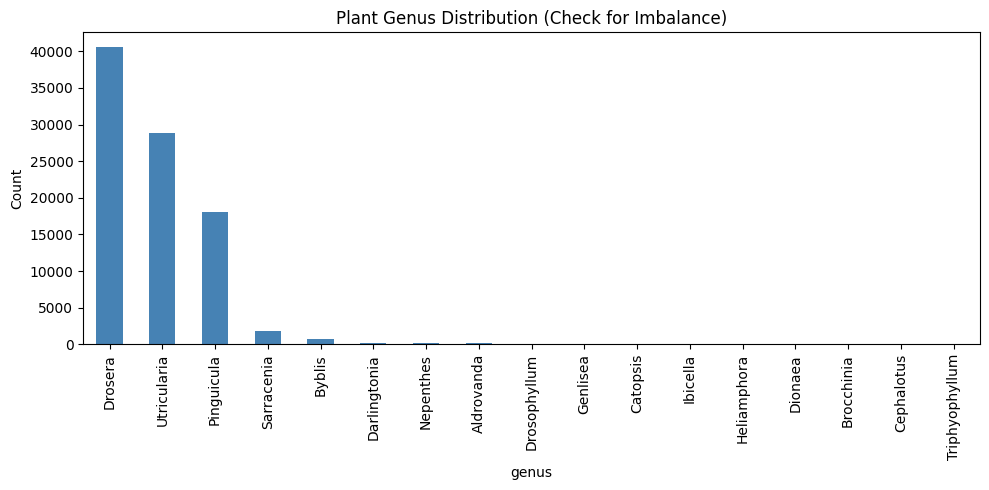

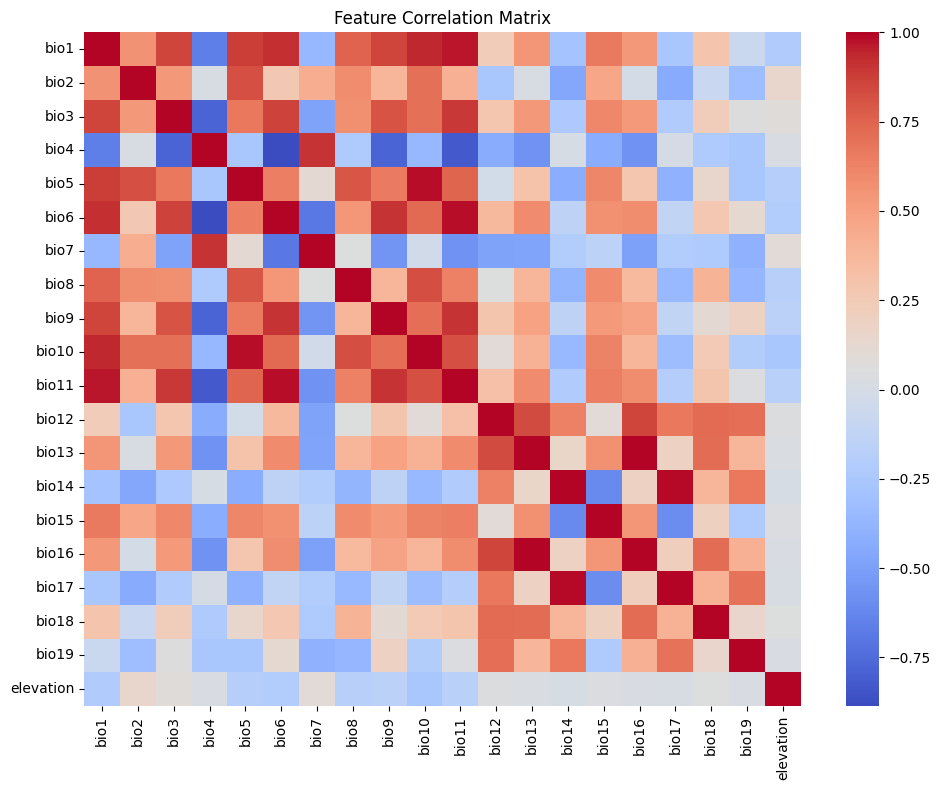


 Cleaned data saved as 'cleaned_carnivorous_plants.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Load data
df = pd.read_csv('Riched Carnivorous Plant.csv')

# 3. Quick look at data
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# 4. Assess Data Quality (Missing Values)
print("\nMissing Values before cleaning:")
print(df.isnull().sum())

# 5. Select features (BIO1-BIO19 + Elevation)
bio_cols = [c for c in df.columns if 'BIO' in c.upper()]
elev_cols = [c for c in df.columns if 'elev' in c.lower()]
features = bio_cols + elev_cols

# 6. Data Cleaning
# Critical Fix: WorldClim missing values are ~ -3.4e+38.
df[features] = df[features].mask(df[features] < -1e30)

# Drop rows with missing values
df_clean = df[features + ['genus']].dropna()
print("\nCleaned data shape:", df_clean.shape)

print("\nSummary Statistics:")
print(df_clean.describe().round(2))

print("\nGenus Distribution:")
counts = df_clean['genus'].value_counts()
print(counts)


plt.figure(figsize=(10, 5))
counts.plot(kind='bar', color='steelblue')
plt.title("Plant Genus Distribution (Check for Imbalance)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[features].corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# 11. Save cleaned data
df_clean.to_csv('cleaned_carnivorous_plants.csv', index=False)
print("\n Cleaned data saved as 'cleaned_carnivorous_plants.csv'")


**Visualization** – Class Distribution

Bar chart shows large imbalance between common and rare genera.

**Insight**: Models must handle imbalance carefully.

**Visualization** – Correlation Matrix

Heatmap shows many climate variables are correlated.

**Insight**: Feature selection may improve performance.



---



### **Neural Network Model – Multi Layer Perceptron**
A neural network can learn complex non-linear relationships between climate and plant genus.

Architecture
**bold text**
Input → climate variables

Hidden Layer 1 → 100 neurons

Hidden Layer 2 → 50 neurons

Activation → ReLU

Optimizer → Adam

Loss → Cross-Entropy (handled internally)




Training Strategy

80% training / 20% testing

StandardScaler used

Target encoded to numeric labels

**Evaluation Metrics**

Accuracy

Precision

Recall

F1-score

Confusion Matrix

A loss curve is also plotted to show learning behavior.

Classes: ['Aldrovanda' 'Brocchinia' 'Byblis' 'Catopsis' 'Cephalotus' 'Darlingtonia'
 'Dionaea' 'Drosera' 'Drosophyllum' 'Genlisea' 'Heliamphora' 'Ibicella'
 'Nepenthes' 'Pinguicula' 'Sarracenia' 'Triphyophyllum' 'Utricularia']

Training Neural Network...

Test Accuracy: 60.43%

--- Classification Report ---
                precision    recall  f1-score   support

    Aldrovanda       0.14      0.05      0.08        19
    Brocchinia       0.00      0.00      0.00        13
        Byblis       0.17      0.01      0.01       140
      Catopsis       0.13      0.11      0.12        19
    Cephalotus       0.00      0.00      0.00        13
  Darlingtonia       0.61      0.49      0.54        39
       Dionaea       0.40      0.15      0.22        13
       Drosera       0.64      0.69      0.66      8185
  Drosophyllum       0.57      0.60      0.59        20
      Genlisea       0.00      0.00      0.00        19
   Heliamphora       0.60      0.38      0.46         8
      Ibicella    

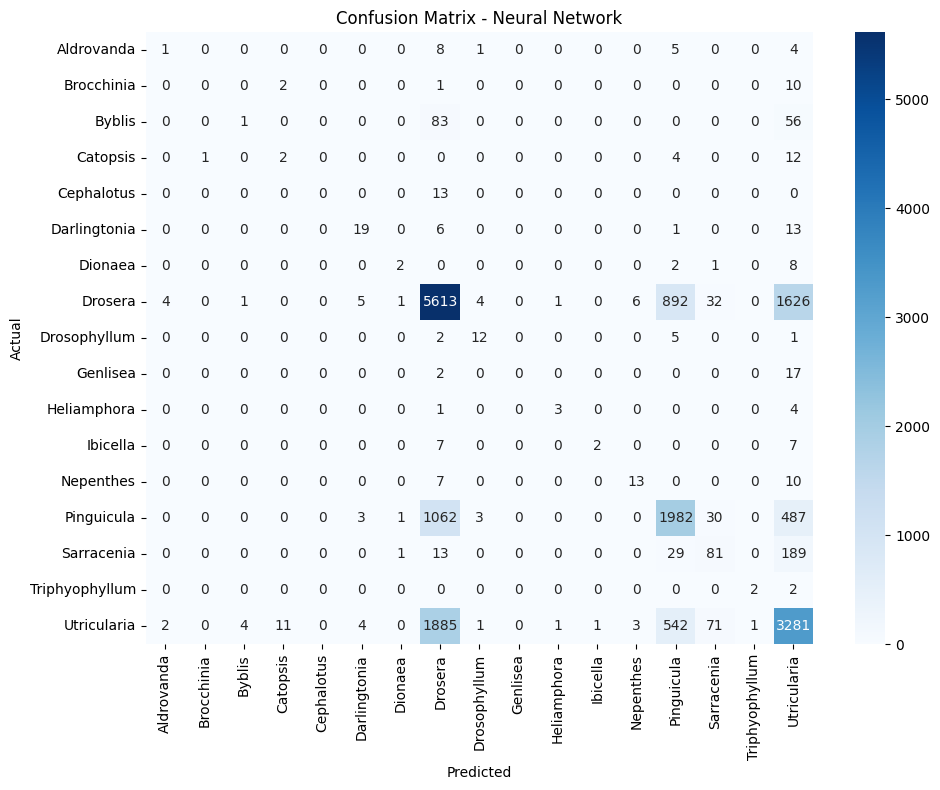

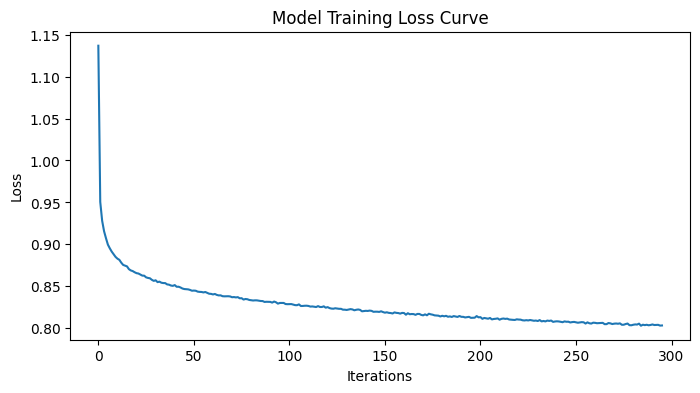

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 1. Load Cleaned Data
df = pd.read_csv('cleaned_carnivorous_plants.csv')

# 2. Features (X) & Target (Y)
X = df.drop('genus', axis=1)
y = df['genus']

# 3. Encode Target (Genus names -> Numbers)
le = LabelEncoder()
y = le.fit_transform(y)
print(f"Classes: {le.classes_}")

# 4. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Build and Train MLP (Multi-Layer Perceptron)
print("\nTraining Neural Network...")
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)


y_pred = mlp.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))


plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_)
plt.title('Model Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()





---



### **Primary Models - Classical Machine Learning**
Two interpretable models

Logistic Regression

A linear baseline model that works well for structured numeric data.

Decision Tree

Captures non-linear rules and interactions.

Handling Imbalance

class_weight = balanced was used.

Evaluation

Models compared using:

Accuracy

Weighted F1-score

The best model is selected based on F1.

Note: Handling class imbalance using class_weight='balanced'

Training and Evaluating Models...

Logistic Regression:
  Test Accuracy: 0.2740
  Weighted F1:   0.2754

Decision Tree:
  Test Accuracy: 0.5021
  Weighted F1:   0.5154

 Best Model Based on Weighted F1: Decision Tree (0.5154)


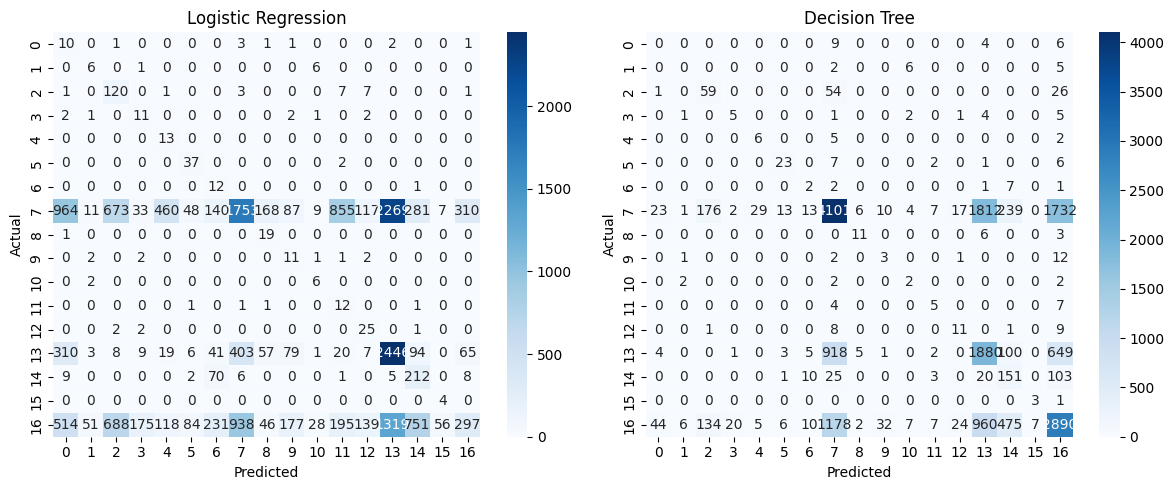

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


# 1. Load Data
df = pd.read_csv('cleaned_carnivorous_plants.csv')
X = df.drop('genus', axis=1)
y = LabelEncoder().fit_transform(df['genus'])

# 2. Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Define Models (Using Dictionary for Cleaner Code)
print("Note: Handling class imbalance using class_weight='balanced'\n")

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

# 4. Train & Evaluate Loop
scores = {}
print("Training and Evaluating Models...")

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Evaluate
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    scores[name] = f1

    print(f"\n{name}:")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Weighted F1:   {f1:.4f}")

best_model = max(scores, key=scores.get)
print(f"\n Best Model Based on Weighted F1: {best_model} ({scores[best_model]:.4f})")


fig, axes = plt.subplots(1, len(models), figsize=(12, 5))

for ax, (name, model) in zip(axes, models.items()):
    sns.heatmap(confusion_matrix(y_test, model.predict(X_test)),
                annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()



### **Hyperparameter Optimization with Cross-Validation**

uned Parameters

Logistic Regression

Regularization strength (C)

Solver

Decision Tree

Max depth

Minimum samples split

To improve fairness and reduce

*   List item
*   List item

overfitting, GridSearchCV (5-fold) was applied.

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('cleaned_carnivorous_plants.csv')
X = df.drop('genus', axis=1)
y = LabelEncoder().fit_transform(df['genus'])

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


# OPTIMIZATION LOOP
models_params = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {'max_depth': [5, 10, 15], 'min_samples_split': [2, 5, 10]}
    }
}

best_scores = {}

for name, mp in models_params.items():
    print(f"\nTuning {name}...")

    # GridSearchCV tests all combinations using 5-fold Cross-Validation
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1_weighted')
    clf.fit(X_train_scaled, y_train)

    print(f"  Best Params: {clf.best_params_}")
    print(f"  Best CV Score: {clf.best_score_:.4f}")
    best_scores[name] = clf.best_score_

print("\n" + "="*40)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*40)

for model, score in best_scores.items():
    print(f"{model}: {score:.4f}")

winner = max(best_scores, key=best_scores.get)
print(f"\n Overall Winner (Best CV Score): {winner} ({best_scores[winner]:.4f})")



Tuning Logistic Regression...


Outcome

Best parameter set and cross-validation score were reported.
Decision Tree achieved the highest CV performance.



---



### **Feature Selection**

Method Used

SelectKBest with ANOVA F-test (filter method).

Why?

It measures how strongly each climate variable helps distinguish plant genera.


Top 10 Most Discriminative Features:
Feature  Score (F-value)
   bio5      1504.797037
  bio10      1492.648292
   bio1      1144.037779
   bio8       993.107393
   bio2       868.710634
   bio3       842.282550
  bio11       806.402827
   bio6       661.818137
  bio15       568.442248
   bio9       551.337124

Weighted F1 (All 20 features): 0.2764
Weighted F1 (Top 10 features): 0.2364


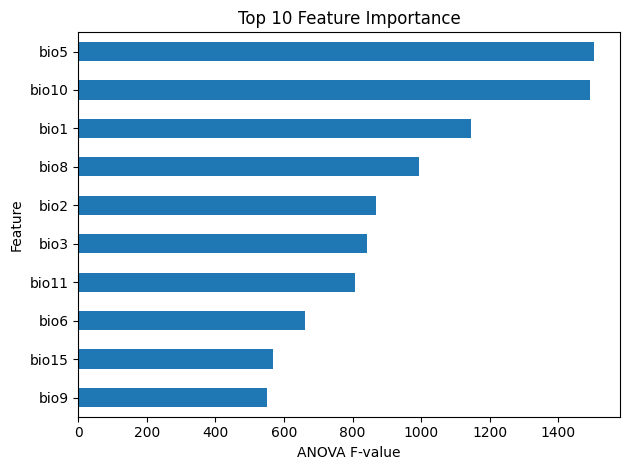

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder


df = pd.read_csv('cleaned_carnivorous_plants.csv')
X = df.drop('genus', axis=1)
y = LabelEncoder().fit_transform(df['genus'])
X_scaled = StandardScaler().fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X_scaled, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score (F-value)': selector.scores_
}).sort_values('Score (F-value)', ascending=False).head(10)

print("\nTop 10 Most Discriminative Features:")
print(feature_scores.to_string(index=False))

def train_eval(features, name):
    X_tr, X_te, y_tr, y_te = train_test_split(features, y, test_size=0.2, random_state=42)
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X_tr, y_tr)
    return f1_score(y_te, model.predict(X_te), average='weighted')

score_all = train_eval(X_scaled, "All Features")
score_sel = train_eval(X_new, "Selected Features")

print(f"\nWeighted F1 (All 20 features): {score_all:.4f}")
print(f"Weighted F1 (Top 10 features): {score_sel:.4f}")


feature_scores.set_index('Feature')['Score (F-value)'].sort_values().plot(kind='barh', title='Top 10 Feature Importance')
plt.xlabel('ANOVA F-value')
plt.tight_layout()
plt.show()




---



### **Final Models & Comparative Analysis**

Models were rebuilt using:


*   best hyperparameters
*   selected features



Final evaluation was performed on the test set.

Metrics:

Accuracy

Precision

Recall

F1-score

A table and bar chart summarize the winner.


Final Comparison:
                      Accuracy  F1 Score
Logistic Regression  0.254581  0.246666
Decision Tree        0.385548  0.406027


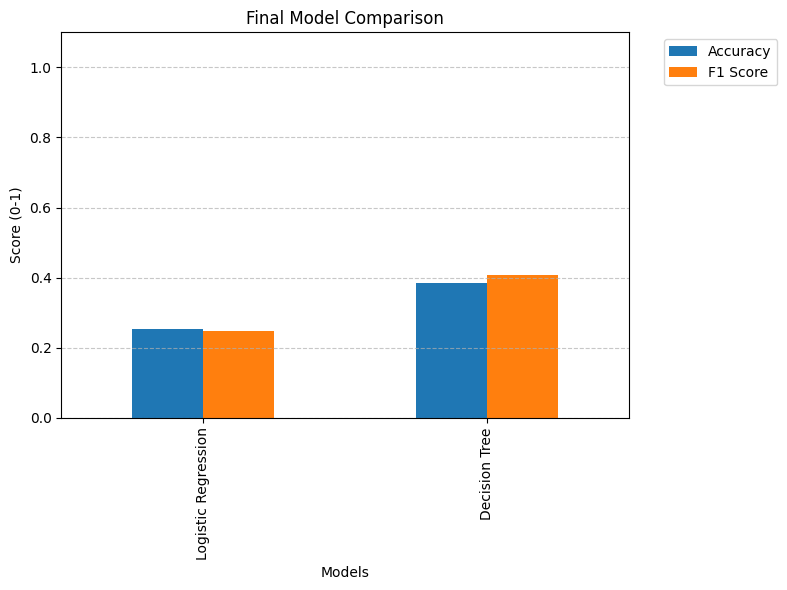


🏆 Winner: Decision Tree!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score

df = pd.read_csv('cleaned_carnivorous_plants.csv')
X = df.drop('genus', axis=1)
y = LabelEncoder().fit_transform(df['genus'])

X_sel = SelectKBest(f_classif, k=10).fit_transform(StandardScaler().fit_transform(X), y)
X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.2, random_state=42)

m1 = LogisticRegression(C=10, solver='lbfgs', class_weight='balanced', max_iter=1000)
m1.fit(X_train, y_train)

# Decision Tree
m2 = DecisionTreeClassifier(max_depth=10, class_weight='balanced')
m2.fit(X_train, y_train)

# 3. Compare
results = {}
for name, model in [("Logistic Regression", m1), ("Decision Tree", m2)]:
    pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred, average='weighted')
    }

res_df = pd.DataFrame(results).T
print("\nFinal Comparison:\n", res_df)

# 4. Visualize
ax = res_df.plot(kind='bar', ylim=(0,1.1), title='Final Model Comparison', figsize=(8, 6))
plt.ylabel('Score (0-1)')
plt.xlabel('Models')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"\n Best Model: {res_df['F1 Score'].idxmax()}!")
